<b>SP500 Volatility Analysis</b>

In [9]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf

In [2]:
# get SP5OO components
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

df = pd.read_html(io.StringIO(response.text), attrs={"id": "constituents"})

comp = df[0][["Security", "Symbol"]]
comp["Symbol"] = comp["Symbol"].str.replace(".", "-")

comp

,Security,Symbol
0,3M,MMM
1,A. O. Smith,AOS
2,Abbott Laboratories,ABT
3,AbbVie,ABBV
4,Accenture,ACN
...,...,...
498,Xylem Inc.,XYL
499,Yum! Brands,YUM
500,Zebra Technologies,ZBRA
501,Zimmer Biomet,ZBH


In [ ]:
# gather closing price, calculate volatilty
rv_1y = {}
rv_90d = {}
rv_30d = {}
for i in range(len(comp)):
    prices = yf.Ticker(comp["Symbol"][i]).history(period="1y")
    prices["ytd_close"] = prices["Close"].shift(1)
    prices = prices.iloc[1:]
    prices["daily_log_return"] = np.log(prices["Close"] / prices["ytd_close"]) * 100
    rv_1y[comp["Symbol"][i]] = np.std(prices["daily_log_return"]) * np.sqrt(252)
    rv_90d[comp["Symbol"][i]] = np.std(prices["daily_log_return"][-90:]) * np.sqrt(252)
    rv_30d[comp["Symbol"][i]] = np.std(prices["daily_log_return"][-30:]) * np.sqrt(252)

comp["1y Realised Vol"] = comp["Symbol"].map(rv_1y)
comp["90d Realised Vol"] = comp["Symbol"].map(rv_90d)
comp["30d Realised Vol"] = comp["Symbol"].map(rv_30d)

comp

,Security,Symbol,1y Realised Vol,90d Realised Vol,30d Realised Vol
0,3M,MMM,25.780340,29.510051,24.102511
1,A. O. Smith,AOS,25.608321,29.209215,31.011907
2,Abbott Laboratories,ABT,23.917110,28.573161,28.766806
3,AbbVie,ABBV,23.815366,26.299833,23.752760
4,Accenture,ACN,34.360869,43.676302,42.013385
...,...,...,...,...,...
498,Xylem Inc.,XYL,23.985563,29.857368,28.981063
499,Yum! Brands,YUM,21.484055,21.966825,22.708595
500,Zebra Technologies,ZBRA,40.899734,45.999634,44.640653
501,Zimmer Biomet,ZBH,31.239271,31.369523,42.008055


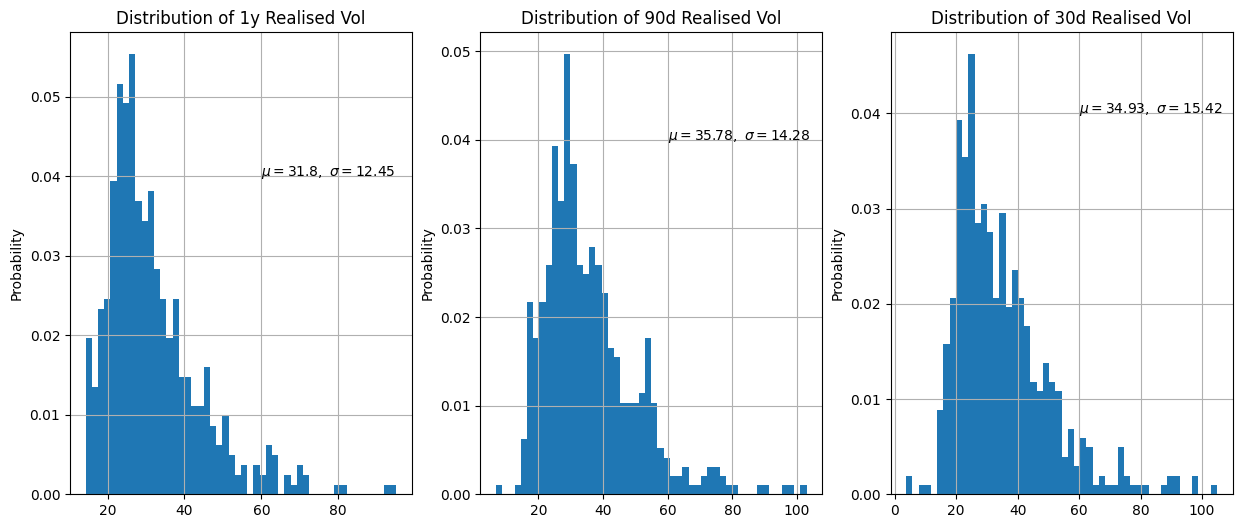

In [28]:
# plots

plt.figure(1, figsize=(15, 6))

for i in range(3):
    plt.subplot(1,3,i + 1)
    mean = np.mean(comp.iloc[:, i + 2])
    std = np.std(comp.iloc[:, i + 2])
    plt.hist(comp.iloc[:, i + 2], 50, density=True)
    plt.title("Distribution of {}".format(comp.columns[i + 2]))
    plt.text(60, .04, r"$\mu={},\ \sigma={}$".format(round(mean, 2), round(std, 2)))
    plt.ylabel("Probability")
    plt.grid(True)
plt.show()

In [2]:
# vol screener
# comp["30/90 difference"] = comp["30d Realised Vol"] - comp["90d Realised Vol"]

